# Chapter 68 — Reflection and Rotation

> **Prerequisites:** ch066 (Function Transformations), ch055 (Inverse Functions)
>
> **You will learn:**
> - Apply reflections across axes and lines
> - Understand rotation as a transformation that preserves distance
> - Connect to even/odd symmetry and inverse function geometry
> - Preview 2D geometric transformations (revisited in Part IV)
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Reflection** across the y-axis: replace x with -x → f(-x)
**Reflection** across the x-axis: negate the output → -f(x)
**Reflection** across y=x: swap x and y → this gives the *inverse function* graph

These are function transformations with specific geometric meaning. They preserve the shape of the function but change its orientation.

**Rotation** of a graph is more complex: it doesn't generally map a function to another function (the vertical line test may fail). However, rotation of data points (as vectors) is a central operation in linear algebra (Part VI).

**Even and odd symmetry:**
- Even function: f(-x) = f(x) — reflection across y-axis leaves it unchanged (e.g., x², cos(x))
- Odd function: f(-x) = -f(x) — 180° rotation around origin (e.g., x³, sin(x))

---

## 2. Intuition & Mental Models

**Physical analogy:** A mirror placed along the y-axis creates the reflection f(-x). A mirror along the x-axis creates -f(x). The y=x mirror (45° diagonal) reveals the inverse function.

**Computational analogy:** `np.flipud` (flip array vertically) and `np.fliplr` (flip horizontally) are discrete reflections of sampled functions.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_21124\3372252161.py:38: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


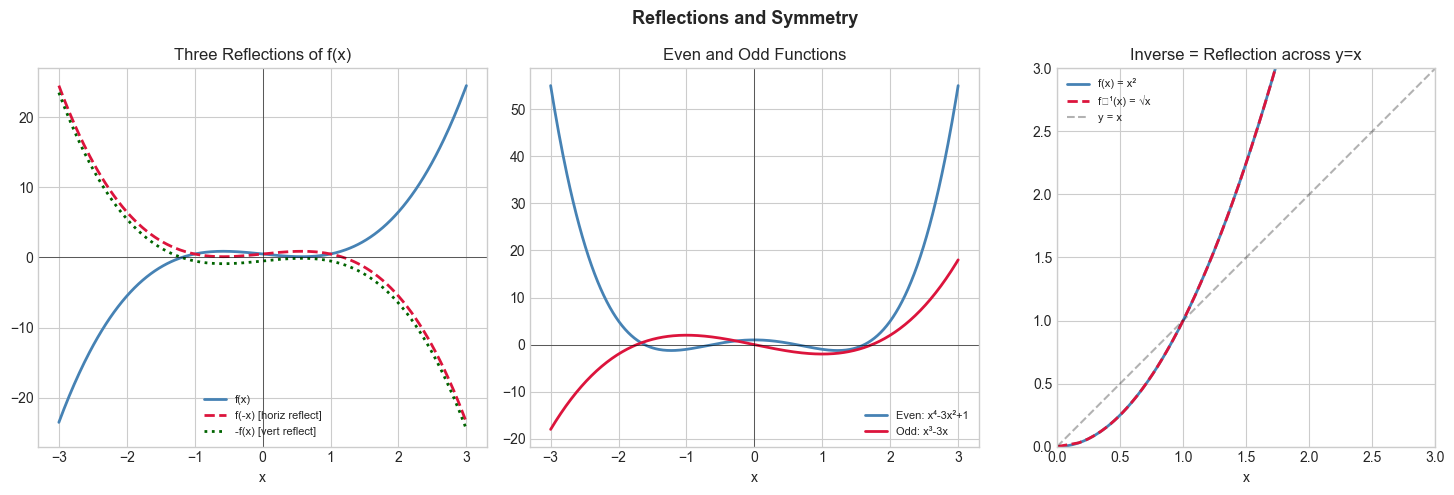

In [1]:
# --- Visualization: Reflections and symmetry ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-3, 3, 400)
f = lambda x: x**3 - x + 0.5  # asymmetric function

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Reflections
axes[0].plot(x, f(x), color='steelblue', linewidth=2, label='f(x)')
axes[0].plot(x, f(-x), color='crimson', linewidth=2, linestyle='--', label='f(-x) [horiz reflect]')
axes[0].plot(x, -f(x), color='darkgreen', linewidth=2, linestyle=':', label='-f(x) [vert reflect]')
axes[0].axhline(0, color='black', linewidth=0.4); axes[0].axvline(0, color='black', linewidth=0.4)
axes[0].set_title('Three Reflections of f(x)'); axes[0].legend(fontsize=8); axes[0].set_xlabel('x')

# Even/Odd symmetry
g_even = lambda x: x**4 - 3*x**2 + 1  # even
g_odd = lambda x: x**3 - 3*x            # odd
axes[1].plot(x, g_even(x), color='steelblue', linewidth=2, label='Even: x⁴-3x²+1')
axes[1].plot(x, g_odd(x), color='crimson', linewidth=2, label='Odd: x³-3x')
axes[1].axhline(0, color='black', linewidth=0.4); axes[1].axvline(0, color='black', linewidth=0.4)
axes[1].set_title('Even and Odd Functions'); axes[1].legend(fontsize=8); axes[1].set_xlabel('x')

# Inverse via y=x reflection
x_pos = np.linspace(0, 3, 300)
f2 = lambda x: x**2
f2_inv = np.sqrt
axes[2].plot(x_pos, f2(x_pos), color='steelblue', linewidth=2, label='f(x) = x²')
axes[2].plot(np.sqrt(np.linspace(0,9,300)), np.linspace(0,9,300),
             color='crimson', linewidth=2, linestyle='--', label='f⁻¹(x) = √x')
axes[2].plot([0,3],[0,3], 'k--', alpha=0.3, label='y = x')
axes[2].set_aspect('equal'); axes[2].set_xlim(0,3); axes[2].set_ylim(0,3)
axes[2].set_title('Inverse = Reflection across y=x'); axes[2].legend(fontsize=8); axes[2].set_xlabel('x')

plt.suptitle('Reflections and Symmetry', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Symmetry decomposition ---
import numpy as np

def decompose_even_odd(f, x):
    """
    Decompose any function into even and odd parts.
    Every function f = f_even + f_odd where:
      f_even(x) = [f(x) + f(-x)] / 2
      f_odd(x)  = [f(x) - f(-x)] / 2
    """
    f_even = (f(x) + f(-x)) / 2
    f_odd  = (f(x) - f(-x)) / 2
    return f_even, f_odd

# Test: decompose exp(x) into cosh(x) and sinh(x)
import numpy as np
x = np.linspace(-2, 2, 400)
f = np.exp

f_even, f_odd = decompose_even_odd(f, x)

print("exp(x) = cosh(x) + sinh(x)")
print("Max error vs np.cosh:", np.max(np.abs(f_even - np.cosh(x))))
print("Max error vs np.sinh:", np.max(np.abs(f_odd - np.sinh(x))))

# Verify f_even + f_odd = f
print("Max reconstruction error:", np.max(np.abs(f_even + f_odd - f(x))))

exp(x) = cosh(x) + sinh(x)
Max error vs np.cosh: 4.440892098500626e-16
Max error vs np.sinh: 4.440892098500626e-16
Max reconstruction error: 4.440892098500626e-16


---

## 6. Experiments

**Experiment 1:** Decompose sin(x) + x² into even and odd parts. What do you get?

**Experiment 2:** Apply reflection f(-x) to a real dataset (negate all x-values). Does the model fitted on original data work on reflected data? (It generally shouldn't — this tests symmetry assumptions.)

---

## 7. Exercises

**Easy 1.** Is f(x) = x²·sin(x) even, odd, or neither? Verify by checking f(-x) vs -f(x) and f(x).

**Easy 2.** Write `reflect_across_yx(f, x_domain)` that computes the inverse function graph by swapping x and y coordinates.

**Medium 1.** Use `decompose_even_odd` on f(x) = 1/(1+e^(-x)) (sigmoid). What are the even and odd parts? The odd part should relate to tanh.

**Medium 2.** Implement a function that tests whether f is even, odd, or neither on a given domain, using numerical evaluation.

**Hard.** Prove: if f is differentiable and even, then f' is odd. If f is odd, then f' is even. Verify numerically using finite differences for f(x) = x⁴ (even) and g(x) = x³ (odd).

---

## 9. Chapter Summary & Connections

- f(-x): horizontal reflection; -f(x): vertical reflection; swap x,y: inverse function
- Even functions symmetric about y-axis; odd functions have 180° rotational symmetry
- Every function = unique even part + unique odd part (decomposition)
- Inverse function graph is the reflection of f across y=x

**Forward connections:**
- Geometric rotation matrices are developed in ch109 (Part IV — Rotation)
- The even/odd decomposition connects to Fourier analysis in signal processing